In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_theme(style='whitegrid')


In [2]:
FILE = r'd:\project\DataScience\Dataset\Document from singhlink4.xlsx'

xl = pd.read_excel(FILE, sheet_name=None)

orders       = xl['orders']
order_items  = xl['order_items']
payments     = xl['order_payments']
reviews      = xl['order_reviews']
customers    = xl['customers']
products     = xl['products']
sellers      = xl['sellers']
geo          = xl['geolocation']
cat_tr       = xl['category_translation']

print("rows per table:")
for name, df in [('orders',orders),('order_items',order_items),('payments',payments),
                 ('reviews',reviews),('customers',customers),('products',products),
                 ('sellers',sellers),('geo',geo),('cat_tr',cat_tr)]:
    print(f"  {name}: {len(df):,}")


rows per table:
  orders: 99,441
  order_items: 112,650
  payments: 103,886
  reviews: 100,000
  customers: 99,441
  products: 32,951
  sellers: 3,095
  geo: 1,000,163
  cat_tr: 71


In [3]:
# quick look at what we have before touching anything
print("order status split:")
print(orders['order_status'].value_counts())

print("\nreview scores:")
sc = reviews['review_score'].value_counts().sort_index()
for k, v in sc.items():
    print(f"  {k} stars: {v:,}  ({100*v/len(reviews):.1f}%)")

print("\nmissing values worth noting:")
for name, df in [('orders',orders),('reviews',reviews),('products',products)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss):
        print(f"\n{name}:")
        print(miss.to_string())


order status split:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

review scores:
  1 stars: 11,858  (11.9%)
  2 stars: 3,235  (3.2%)
  3 stars: 8,287  (8.3%)
  4 stars: 19,200  (19.2%)
  5 stars: 57,420  (57.4%)

missing values worth noting:

orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

reviews:
review_comment_title      88285
review_comment_message    58247

products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2


In [4]:
# parse dates
date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_carrier_date','order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

reviews['review_creation_date']    = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')

# time helpers
orders['ym']    = orders['order_purchase_timestamp'].dt.to_period('M')
orders['year']  = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month

# only delivered orders matter for delivery analysis
delivered = orders[orders['order_status'] == 'delivered'].copy()

# positive = late, negative = early
delivered['delay'] = (
    (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date'])
    .dt.total_seconds() / 86400
)
delivered['days_taken'] = (
    (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp'])
    .dt.total_seconds() / 86400
)
delivered['ym'] = delivered['order_purchase_timestamp'].dt.to_period('M')

def delay_label(d):
    if pd.isna(d): return 'unknown'
    if d < -7:  return '>1wk early'
    if d <  0:  return 'early'
    if d <= 3:  return 'on time'
    if d <= 7:  return '3-7d late'
    if d <= 14: return '7-14d late'
    return '14d+ late'

DELAY_ORDER = ['>1wk early','early','on time','3-7d late','7-14d late','14d+ late']
delivered['delay_label'] = delivered['delay'].apply(delay_label)

# English product categories
products_en = products.merge(cat_tr, on='product_category_name', how='left')
products_en['cat'] = (products_en['product_category_name_english']
                      .fillna(products_en['product_category_name'])
                      .fillna('unknown'))

# items table with seller + product info
items = (order_items
    .merge(products_en[['product_id','cat','product_weight_g',
                         'product_length_cm','product_height_cm',
                         'product_width_cm','product_photos_qty',
                         'product_description_lenght','product_name_lenght']],
           on='product_id', how='left')
    .merge(sellers[['seller_id','seller_state']], on='seller_id', how='left')
)

# payment per order
pay = payments.groupby('order_id').agg(
    total_paid       = ('payment_value',        'sum'),
    ptype            = ('payment_type',         lambda x: x.mode()[0]),
    max_installments = ('payment_installments', 'max')
).reset_index()

# revenue per order
rev_agg = order_items.groupby('order_id').agg(
    item_rev  = ('price',        'sum'),
    freight   = ('freight_value','sum'),
    n_items   = ('order_item_id','count')
).reset_index()
rev_agg['order_val'] = rev_agg['item_rev'] + rev_agg['freight']

# master: delivered + reviews + customers + payments + revenue
master = (delivered
    .merge(reviews[['order_id','review_score','review_comment_message',
                    'review_creation_date','review_answer_timestamp']],
           on='order_id', how='left')
    .merge(customers[['customer_id','customer_state','customer_unique_id']],
           on='customer_id', how='left')
    .merge(pay,     on='order_id', how='left')
    .merge(rev_agg, on='order_id', how='left')
)

master['low_score'] = master['review_score'].isin([1,2]).astype(float)
master['is_late']   = (master['delay'] > 0).astype(float)

print(f"master: {len(master):,} rows")
print(f"late:   {master['is_late'].sum():,.0f}  ({100*master['is_late'].mean():.1f}%)")
print(f"low score (1-2): {master['low_score'].sum():,.0f}  ({100*master['low_score'].mean():.1f}%)")


master: 97,015 rows
late:   7,865  (8.1%)
low score (1-2): 12,769  (13.2%)


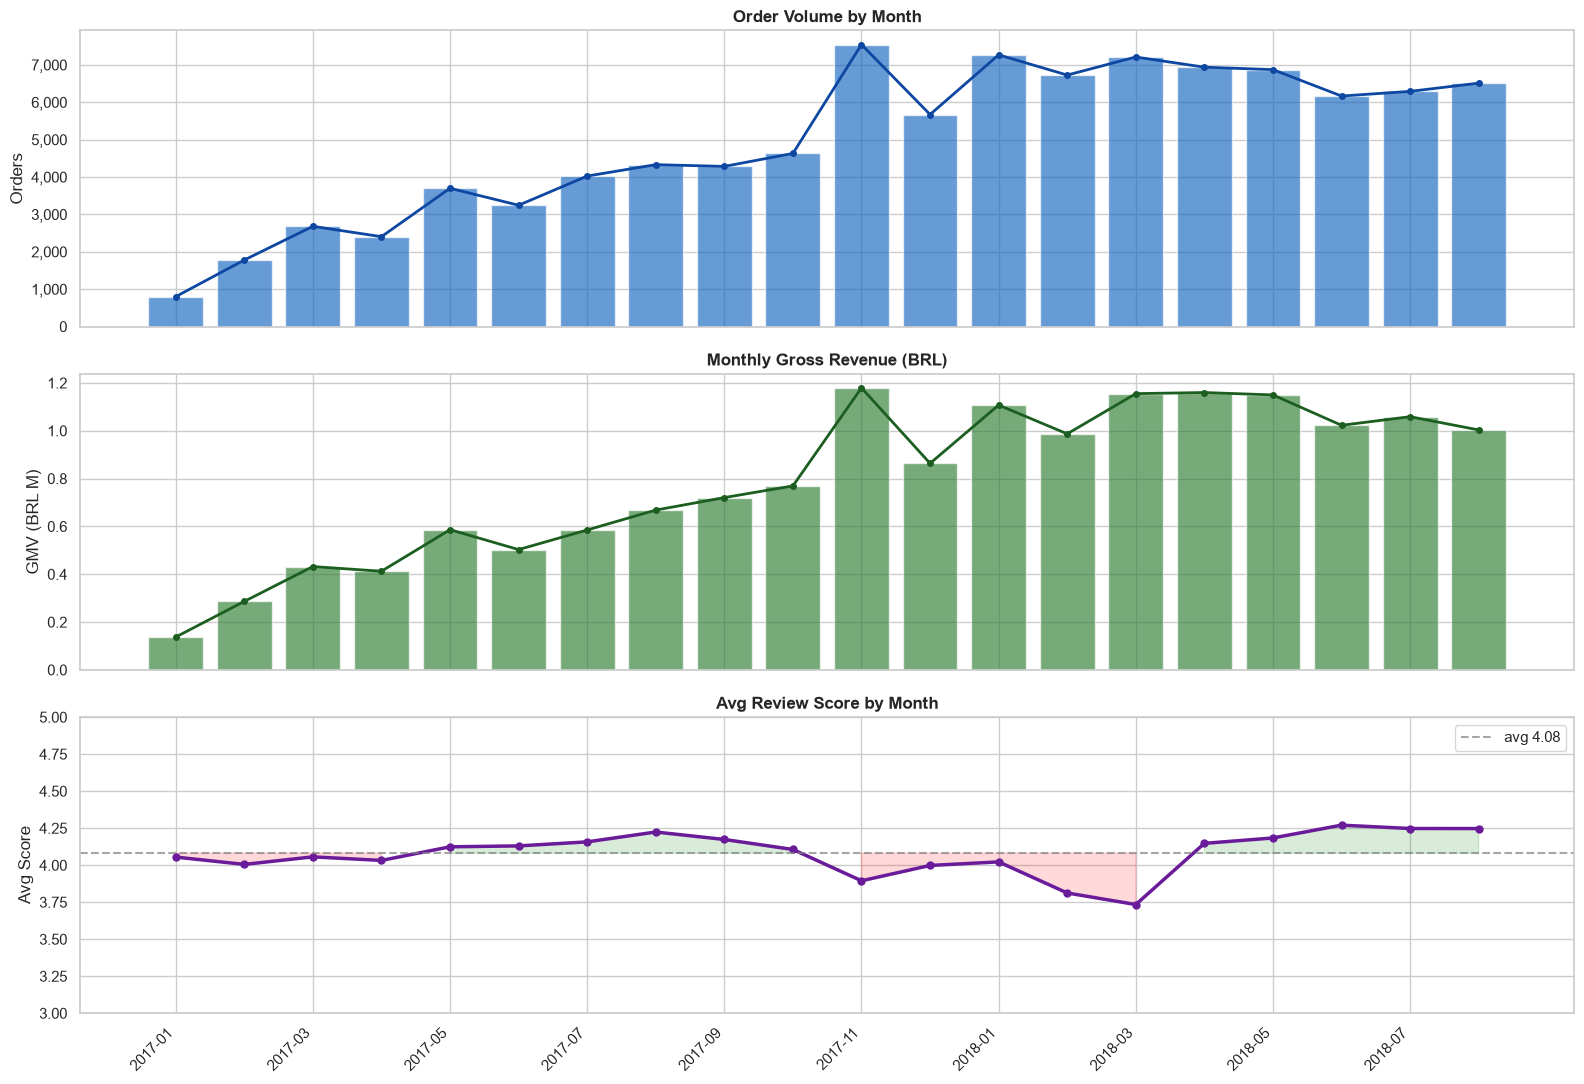

orders: 800 -> 6,512
GMV:    0.1M -> 1.0M
score:  4.05 -> 4.25


In [5]:
S, E = '2017-01', '2018-08'  # full months only

vol = (orders.groupby('ym').agg(cnt=('order_id','count')).reset_index())
vol['ym_str'] = vol['ym'].astype(str)
vol = vol[vol['ym_str'].between(S, E)]

gmv = (order_items.merge(orders[['order_id','ym']], on='order_id')
       .groupby('ym').agg(gmv=('price','sum'), frt=('freight_value','sum')).reset_index())
gmv['total'] = gmv['gmv'] + gmv['frt']
gmv['ym_str'] = gmv['ym'].astype(str)
gmv = gmv[gmv['ym_str'].between(S, E)]

sc = (reviews.merge(orders[['order_id','ym']], on='order_id')
      .groupby('ym').agg(avg=('review_score','mean'),
                          pct_low=('review_score', lambda x: (x<=2).mean()*100))
      .reset_index())
sc['ym_str'] = sc['ym'].astype(str)
sc = sc[sc['ym_str'].between(S, E)]

df_m = vol.merge(gmv[['ym','total']], on='ym').merge(sc[['ym','avg','pct_low']], on='ym')
x = np.arange(len(df_m))
lbl = df_m['ym_str'].tolist()

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

axes[0].bar(x, df_m['cnt'], color='#1565C0', alpha=0.65, edgecolor='white')
axes[0].plot(x, df_m['cnt'], 'o-', color='#0D47A1', lw=2, ms=4)
axes[0].set_ylabel('Orders'); axes[0].set_title('Order Volume by Month', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

axes[1].bar(x, df_m['total']/1e6, color='#2E7D32', alpha=0.65, edgecolor='white')
axes[1].plot(x, df_m['total']/1e6, 'o-', color='#1B5E20', lw=2, ms=4)
axes[1].set_ylabel('GMV (BRL M)'); axes[1].set_title('Monthly Gross Revenue (BRL)', fontweight='bold')

ovr = df_m['avg'].mean()
axes[2].plot(x, df_m['avg'], 'o-', color='#6A1B9A', lw=2.5, ms=5)
axes[2].axhline(ovr, ls='--', color='gray', alpha=0.7, label=f'avg {ovr:.2f}')
axes[2].fill_between(x, df_m['avg'], ovr,
                     where=(df_m['avg'] >= ovr), alpha=0.15, color='green')
axes[2].fill_between(x, df_m['avg'], ovr,
                     where=(df_m['avg'] < ovr),  alpha=0.15, color='red')
axes[2].set_ylim(3.0, 5.0); axes[2].legend()
axes[2].set_ylabel('Avg Score'); axes[2].set_title('Avg Review Score by Month', fontweight='bold')
axes[2].set_xticks(x[::2]); axes[2].set_xticklabels(lbl[::2], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('q1_trends.png', bbox_inches='tight', dpi=150)
plt.show()

# orders roughly tripled, but review score did not move as much
print(f"orders: {df_m.iloc[0]['cnt']:,} -> {df_m.iloc[-1]['cnt']:,}")
print(f"GMV:    {df_m.iloc[0]['total']/1e6:.1f}M -> {df_m.iloc[-1]['total']/1e6:.1f}M")
print(f"score:  {df_m.iloc[0]['avg']:.2f} -> {df_m.iloc[-1]['avg']:.2f}")


correlation (delay vs score): r = -0.269,  p = 0.00e+00
delay_label  avg_score   pct_low  count
 >1wk early   4.305971  9.246193  71716
      early   4.188626 10.576151  17426
    on time   3.748226 19.574150   2677
  3-7d late   2.296764 61.876029   1823
 7-14d late   1.743333 78.222222   1800
  14d+ late   1.705431 78.849840   1565


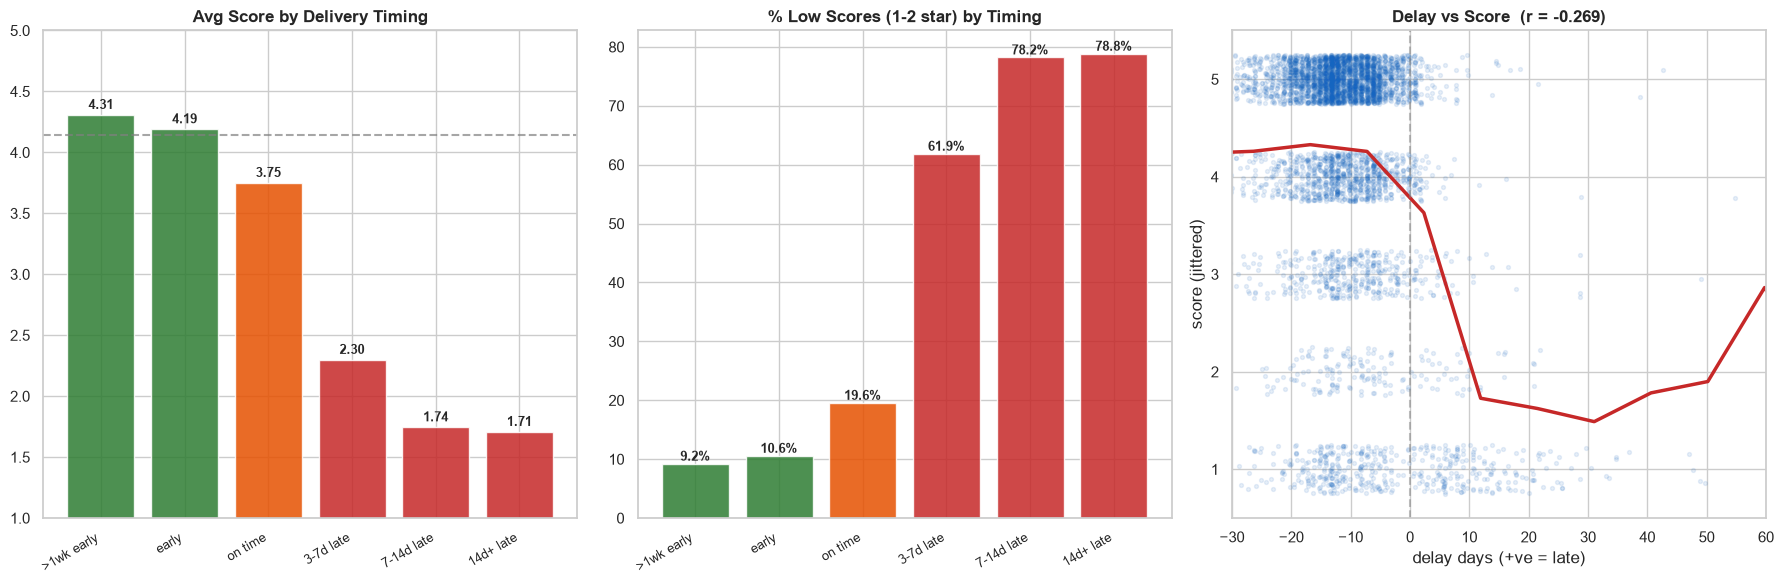

In [6]:
delay_stats = (master[master['delay_label'] != 'unknown']
    .groupby('delay_label')
    .agg(avg_score=('review_score','mean'),
         pct_low  =('low_score',   'mean'),
         count    =('order_id',    'count'))
    .reindex(DELAY_ORDER).reset_index())
delay_stats['pct_low'] *= 100

r, p = stats.pearsonr(*master[['delay','review_score']].dropna().T.values)
print(f"correlation (delay vs score): r = {r:.3f},  p = {p:.2e}")
print(delay_stats.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# avg score per bucket
c1 = ['#2E7D32' if s >= 4.0 else '#E65100' if s >= 3.5 else '#C62828'
      for s in delay_stats['avg_score']]
b = axes[0].bar(range(len(delay_stats)), delay_stats['avg_score'],
                color=c1, edgecolor='white', alpha=0.85)
axes[0].axhline(master['review_score'].mean(), ls='--', color='gray', alpha=0.7)
axes[0].set_xticks(range(len(delay_stats)))
axes[0].set_xticklabels(delay_stats['delay_label'], rotation=30, ha='right', fontsize=9)
axes[0].set_ylim(1, 5); axes[0].set_title('Avg Score by Delivery Timing', fontweight='bold')
for bar, v in zip(b, delay_stats['avg_score']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}',
                 ha='center', fontsize=9, fontweight='bold')

# % low scores
c2 = ['#C62828' if p > 30 else '#E65100' if p > 15 else '#2E7D32'
      for p in delay_stats['pct_low']]
b2 = axes[1].bar(range(len(delay_stats)), delay_stats['pct_low'],
                 color=c2, edgecolor='white', alpha=0.85)
axes[1].set_xticks(range(len(delay_stats)))
axes[1].set_xticklabels(delay_stats['delay_label'], rotation=30, ha='right', fontsize=9)
axes[1].set_title('% Low Scores (1-2 star) by Timing', fontweight='bold')
for bar, v in zip(b2, delay_stats['pct_low']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# scatter with trend
samp = master[['delay','review_score']].dropna().sample(5000, random_state=1)
axes[2].scatter(samp['delay'],
                samp['review_score'] + np.random.uniform(-0.25, 0.25, len(samp)),
                alpha=0.1, s=8, color='#1565C0')
binned = (master[['delay','review_score']].dropna()
          .assign(b=lambda d: pd.cut(d['delay'], 35))
          .groupby('b')['review_score'].mean())
axes[2].plot([b.mid for b in binned.index], binned.values, '-', color='#C62828', lw=2.5)
axes[2].axvline(0, ls='--', color='gray', alpha=0.5)
axes[2].set_xlim(-30, 60); axes[2].set_ylim(0.5, 5.5)
axes[2].set_xlabel('delay days (+ve = late)')
axes[2].set_ylabel('score (jittered)')
axes[2].set_title(f'Delay vs Score  (r = {r:.3f})', fontweight='bold')

plt.tight_layout()
plt.savefig('q2_delivery_score.png', bbox_inches='tight', dpi=150)
plt.show()


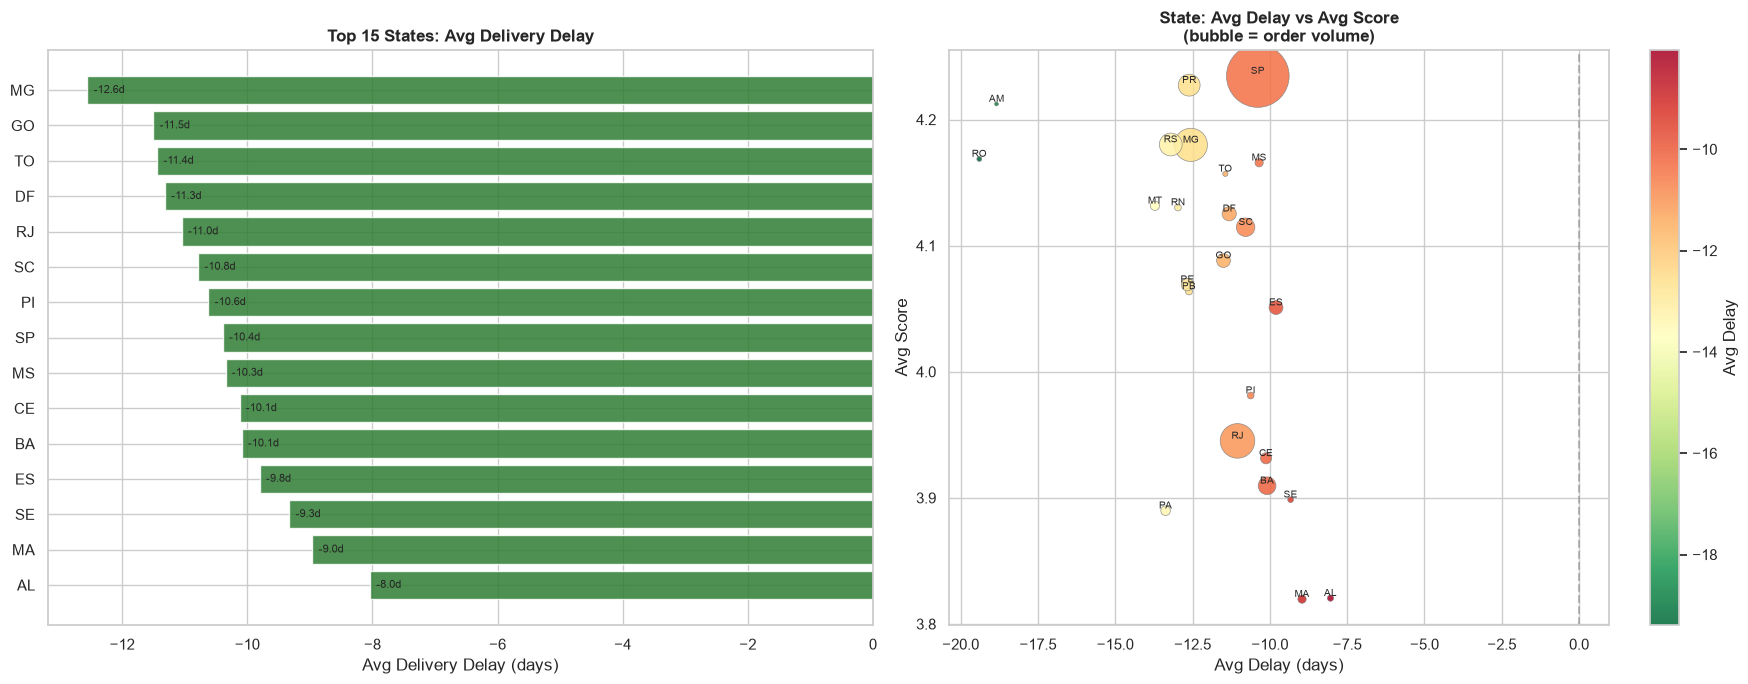

In [7]:
st = (master.groupby('customer_state')
      .agg(avg_score=('review_score','mean'),
           avg_delay=('delay','mean'),
           pct_late =('is_late','mean'),
           cnt      =('order_id','count'))
      .query('cnt >= 100').reset_index())
st['pct_late'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# top states by delay
top = st.sort_values('avg_delay', ascending=False).head(15)
axes[0].barh(top['customer_state'], top['avg_delay'],
             color=['#C62828' if d > 5 else '#E65100' if d > 0 else '#2E7D32'
                    for d in top['avg_delay']],
             edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='gray', lw=1, ls='--', alpha=0.6)
axes[0].set_xlabel('Avg Delivery Delay (days)')
axes[0].set_title('Top 15 States: Avg Delivery Delay', fontweight='bold')
for i, (s, d) in enumerate(zip(top['customer_state'], top['avg_delay'])):
    axes[0].text(d + 0.1, i, f'{d:.1f}d', va='center', fontsize=8)

# scatter delay vs score by state
sc_plot = axes[1].scatter(st['avg_delay'], st['avg_score'],
                           s=st['cnt']/20,
                           c=st['avg_delay'], cmap='RdYlGn_r',
                           alpha=0.85, edgecolors='grey', lw=0.5)
for _, row in st.iterrows():
    axes[1].annotate(row['customer_state'],
                     (row['avg_delay'], row['avg_score']),
                     fontsize=7.5, ha='center', va='bottom')
axes[1].axvline(0, ls='--', color='gray', alpha=0.5)
axes[1].set_xlabel('Avg Delay (days)'); axes[1].set_ylabel('Avg Score')
axes[1].set_title('State: Avg Delay vs Avg Score\n(bubble = order volume)', fontweight='bold')
plt.colorbar(sc_plot, ax=axes[1], label='Avg Delay')

plt.tight_layout()
plt.savefig('q2_by_state.png', bbox_inches='tight', dpi=150)
plt.show()


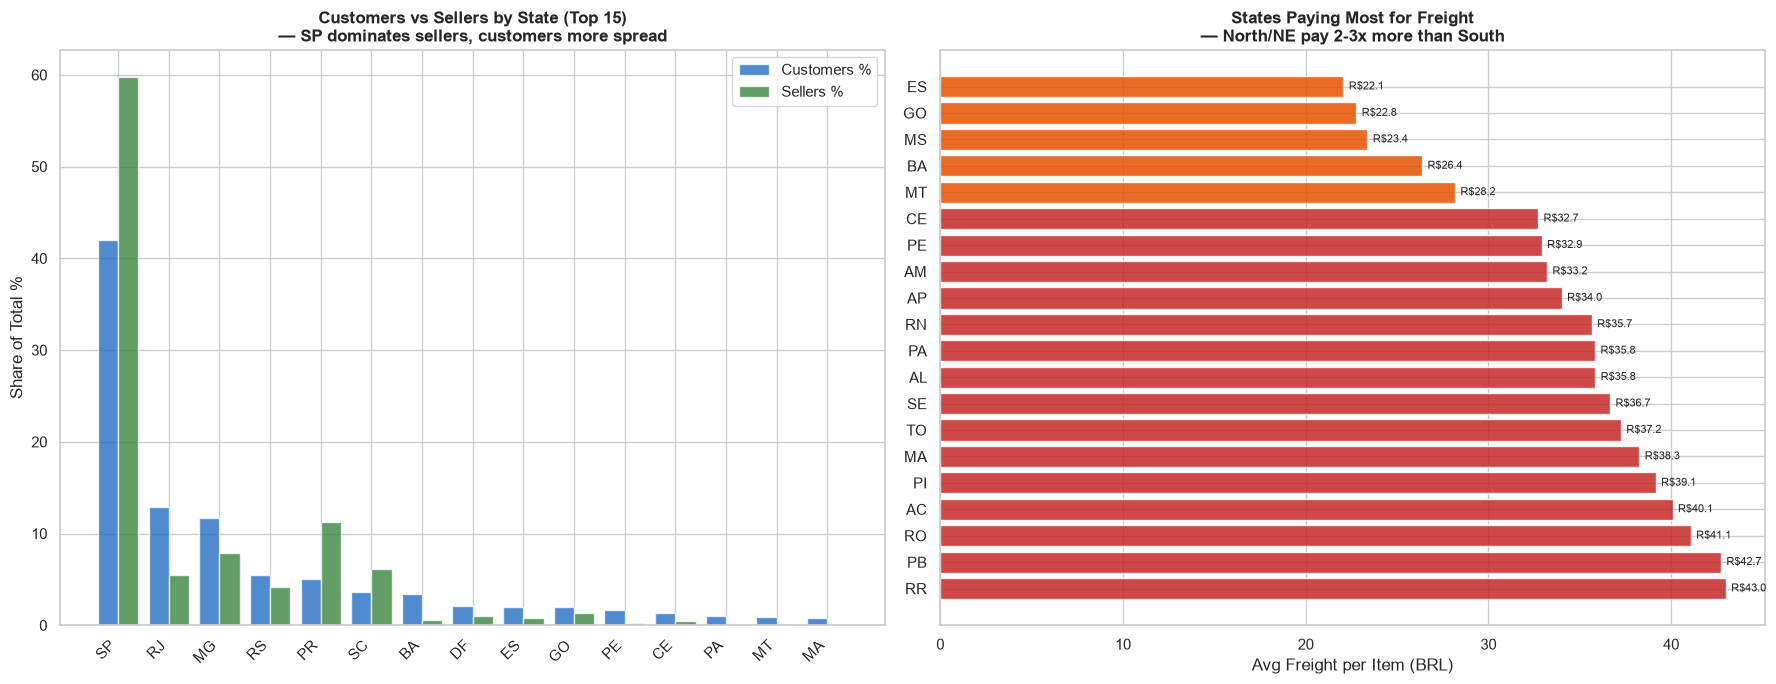

SP seller share: 59.7%  |  SP customer share: 42.0%
this imbalance is the structural cause of long-distance shipping delays


In [8]:
cst = customers.groupby('customer_state').size().reset_index(name='custs')
sst = sellers.groupby('seller_state').size().reset_index(name='sellers')

geo_df = (cst.rename(columns={'customer_state':'state'})
          .merge(sst.rename(columns={'seller_state':'state'}), on='state', how='outer')
          .fillna(0))
geo_df['cust_pct']   = 100 * geo_df['custs']   / geo_df['custs'].sum()
geo_df['seller_pct'] = 100 * geo_df['sellers'] / geo_df['sellers'].sum()
geo_df = geo_df.sort_values('custs', ascending=False)

# freight per state
frt = (order_items
    .merge(orders[['order_id','customer_id']], on='order_id')
    .merge(customers[['customer_id','customer_state']], on='customer_id')
    .groupby('customer_state')
    .agg(avg_frt=('freight_value','mean'), cnt=('order_id','count'))
    .reset_index().sort_values('avg_frt', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# customer vs seller share
top15 = geo_df.head(15)
x = np.arange(len(top15)); w = 0.4
axes[0].bar(x-w/2, top15['cust_pct'],   w, label='Customers %', color='#1565C0', alpha=0.75)
axes[0].bar(x+w/2, top15['seller_pct'], w, label='Sellers %',   color='#2E7D32', alpha=0.75)
axes[0].set_xticks(x); axes[0].set_xticklabels(top15['state'], rotation=45, ha='right')
axes[0].set_ylabel('Share of Total %'); axes[0].legend()
axes[0].set_title('Customers vs Sellers by State (Top 15)\n— SP dominates sellers, customers more spread',
                  fontweight='bold')

# avg freight top 20
top20f = frt.head(20)
fc = ['#C62828' if f>30 else '#E65100' if f>20 else '#2E7D32' for f in top20f['avg_frt']]
axes[1].barh(top20f['customer_state'], top20f['avg_frt'], color=fc, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Avg Freight per Item (BRL)')
axes[1].set_title('States Paying Most for Freight\n— North/NE pay 2-3x more than South', fontweight='bold')
for i, (s, f) in enumerate(zip(top20f['customer_state'], top20f['avg_frt'])):
    axes[1].text(f+0.3, i, f'R${f:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('q3_geography.png', bbox_inches='tight', dpi=150)
plt.show()

sp_sell = geo_df[geo_df['state']=='SP']['seller_pct'].values[0]
sp_cust = geo_df[geo_df['state']=='SP']['cust_pct'].values[0]
print(f"SP seller share: {sp_sell:.1f}%  |  SP customer share: {sp_cust:.1f}%")
print("this imbalance is the structural cause of long-distance shipping delays")


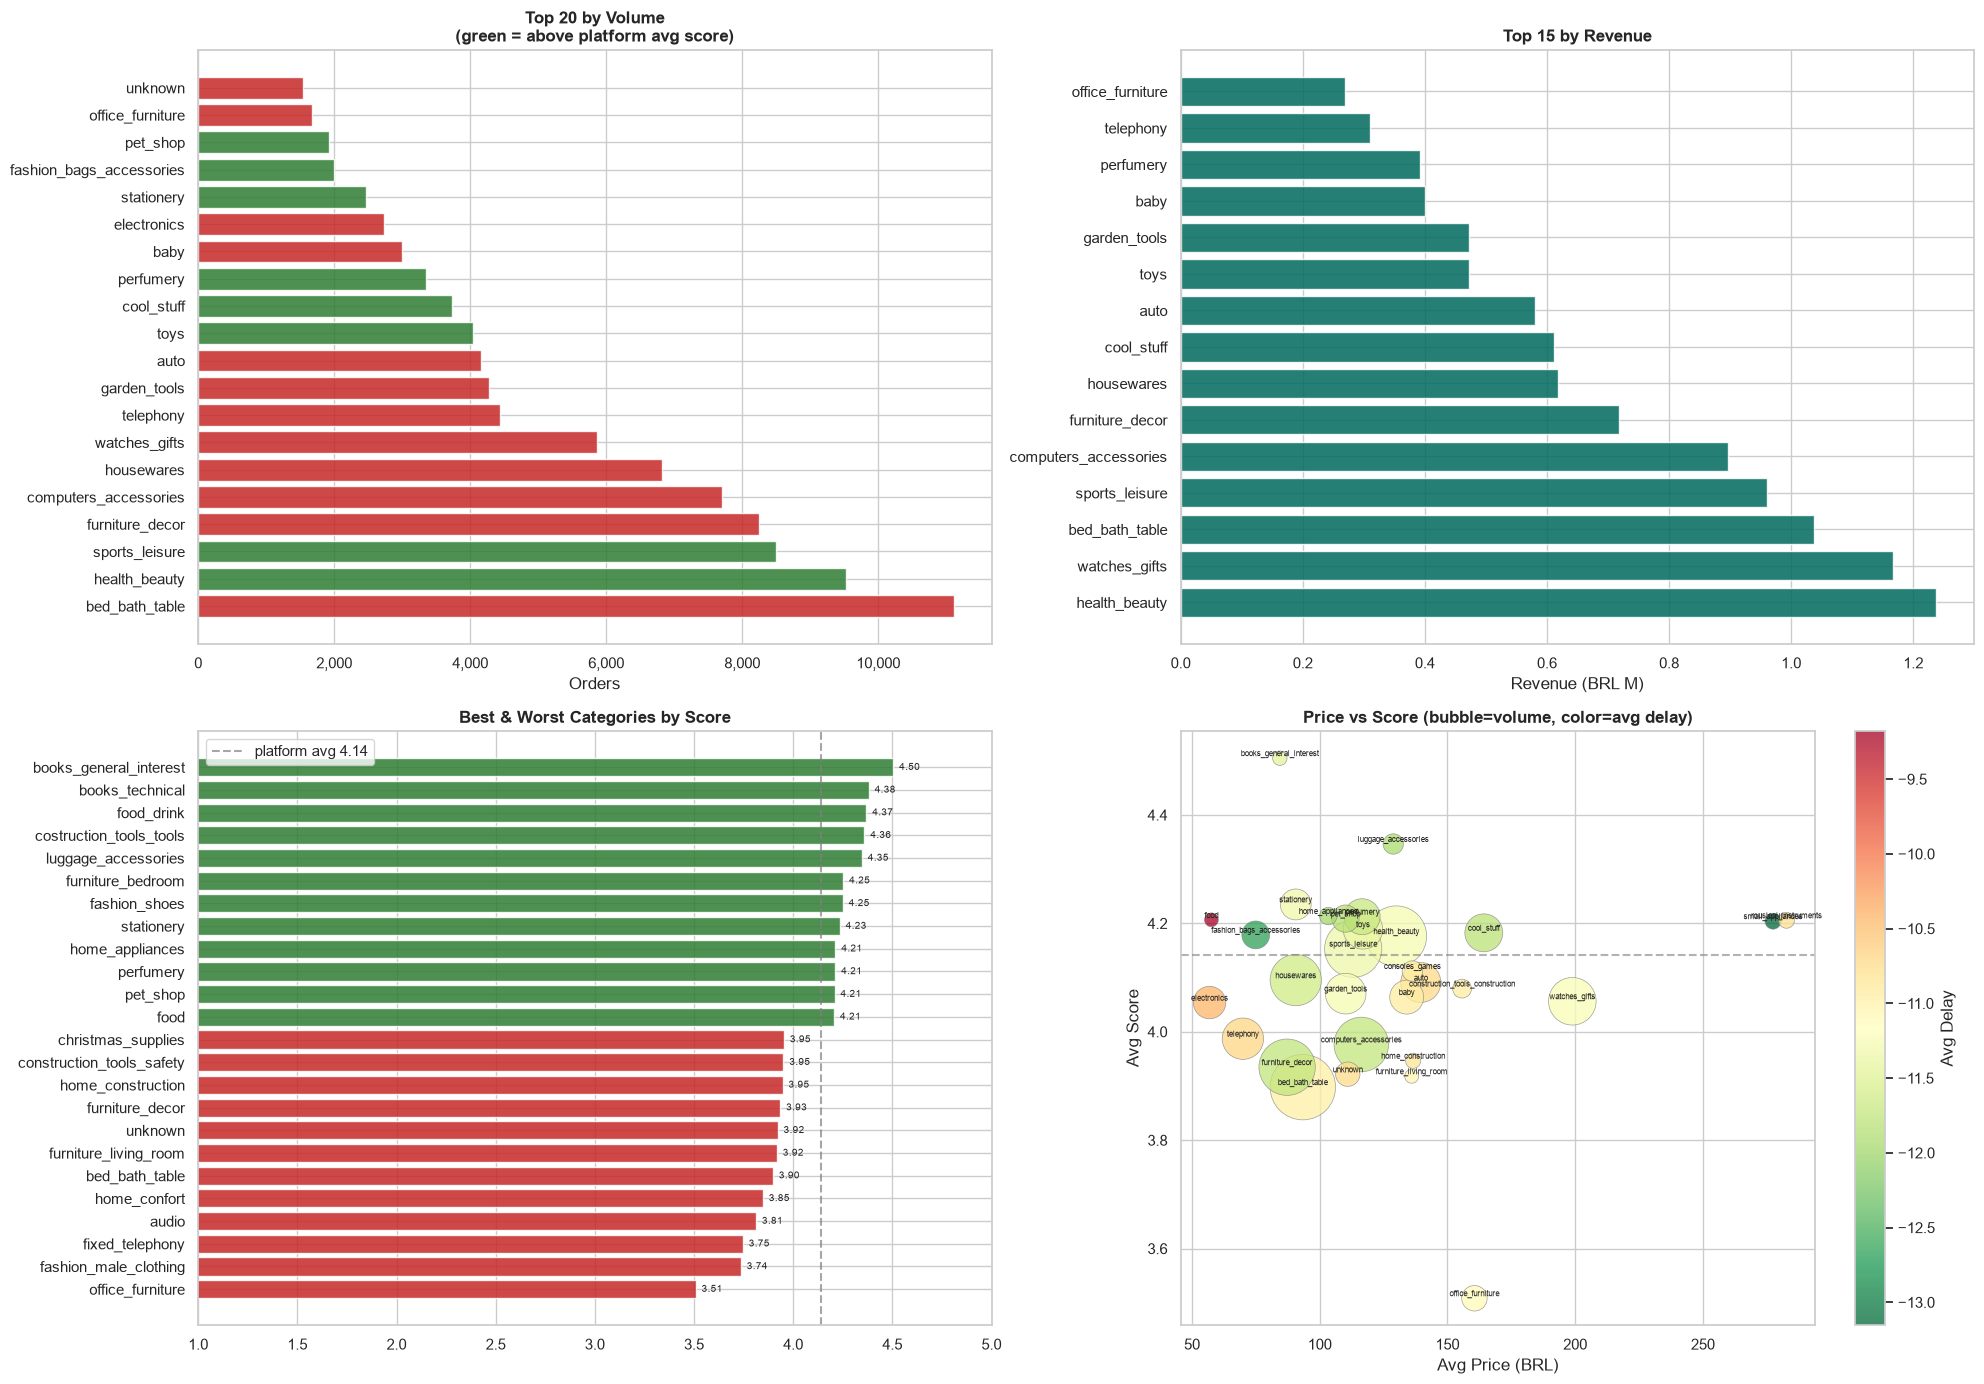

In [9]:
items_sc = items.merge(master[['order_id','review_score','delay']], on='order_id', how='inner')

cats = (items_sc.groupby('cat')
    .agg(orders   =('order_id',     'count'),
         avg_price=('price',        'mean'),
         revenue  =('price',        'sum'),
         avg_frt  =('freight_value','mean'),
         avg_score=('review_score', 'mean'),
         pct_low  =('review_score', lambda x: (x<=2).mean()*100),
         avg_delay=('delay',        'mean'))
    .reset_index().query('orders >= 100'))

platform_avg = master['review_score'].mean()

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# volume
top20v = cats.nlargest(20, 'orders')
vc = ['#2E7D32' if s >= platform_avg else '#C62828' for s in top20v['avg_score']]
axes[0,0].barh(top20v['cat'], top20v['orders'], color=vc, edgecolor='white', alpha=0.85)
axes[0,0].set_xlabel('Orders')
axes[0,0].set_title('Top 20 by Volume\n(green = above platform avg score)', fontweight='bold')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

# revenue
top15r = cats.nlargest(15, 'revenue')
axes[0,1].barh(top15r['cat'], top15r['revenue']/1e6, color='#00695C', edgecolor='white', alpha=0.85)
axes[0,1].set_xlabel('Revenue (BRL M)'); axes[0,1].set_title('Top 15 by Revenue', fontweight='bold')

# best and worst scores
worst = cats.nsmallest(12, 'avg_score')
best  = cats.nlargest(12,  'avg_score')
bw = pd.concat([worst, best]).drop_duplicates('cat').sort_values('avg_score')
bc = ['#C62828' if s < platform_avg else '#2E7D32' for s in bw['avg_score']]
axes[1,0].barh(bw['cat'], bw['avg_score'], color=bc, edgecolor='white', alpha=0.85)
axes[1,0].axvline(platform_avg, ls='--', color='gray', alpha=0.7,
                   label=f'platform avg {platform_avg:.2f}')
axes[1,0].set_xlim(1,5); axes[1,0].legend()
axes[1,0].set_title('Best & Worst Categories by Score', fontweight='bold')
for i, (c, s) in enumerate(zip(bw['cat'], bw['avg_score'])):
    axes[1,0].text(s+0.03, i, f'{s:.2f}', va='center', fontsize=7.5)

# price vs score bubble
bubble = cats.query('orders >= 200').nlargest(30, 'orders')
sc_b = axes[1,1].scatter(bubble['avg_price'], bubble['avg_score'],
                          s=bubble['orders']/5, c=bubble['avg_delay'],
                          cmap='RdYlGn_r', alpha=0.75, edgecolors='grey', lw=0.5)
for _, row in bubble.iterrows():
    axes[1,1].annotate(row['cat'], (row['avg_price'], row['avg_score']),
                       fontsize=6, ha='center', va='bottom')
axes[1,1].axhline(platform_avg, ls='--', color='gray', alpha=0.6)
axes[1,1].set_xlabel('Avg Price (BRL)'); axes[1,1].set_ylabel('Avg Score')
axes[1,1].set_title('Price vs Score (bubble=volume, color=avg delay)', fontweight='bold')
plt.colorbar(sc_b, ax=axes[1,1], label='Avg Delay')

plt.tight_layout()
plt.savefig('q4_categories.png', bbox_inches='tight', dpi=150)
plt.show()


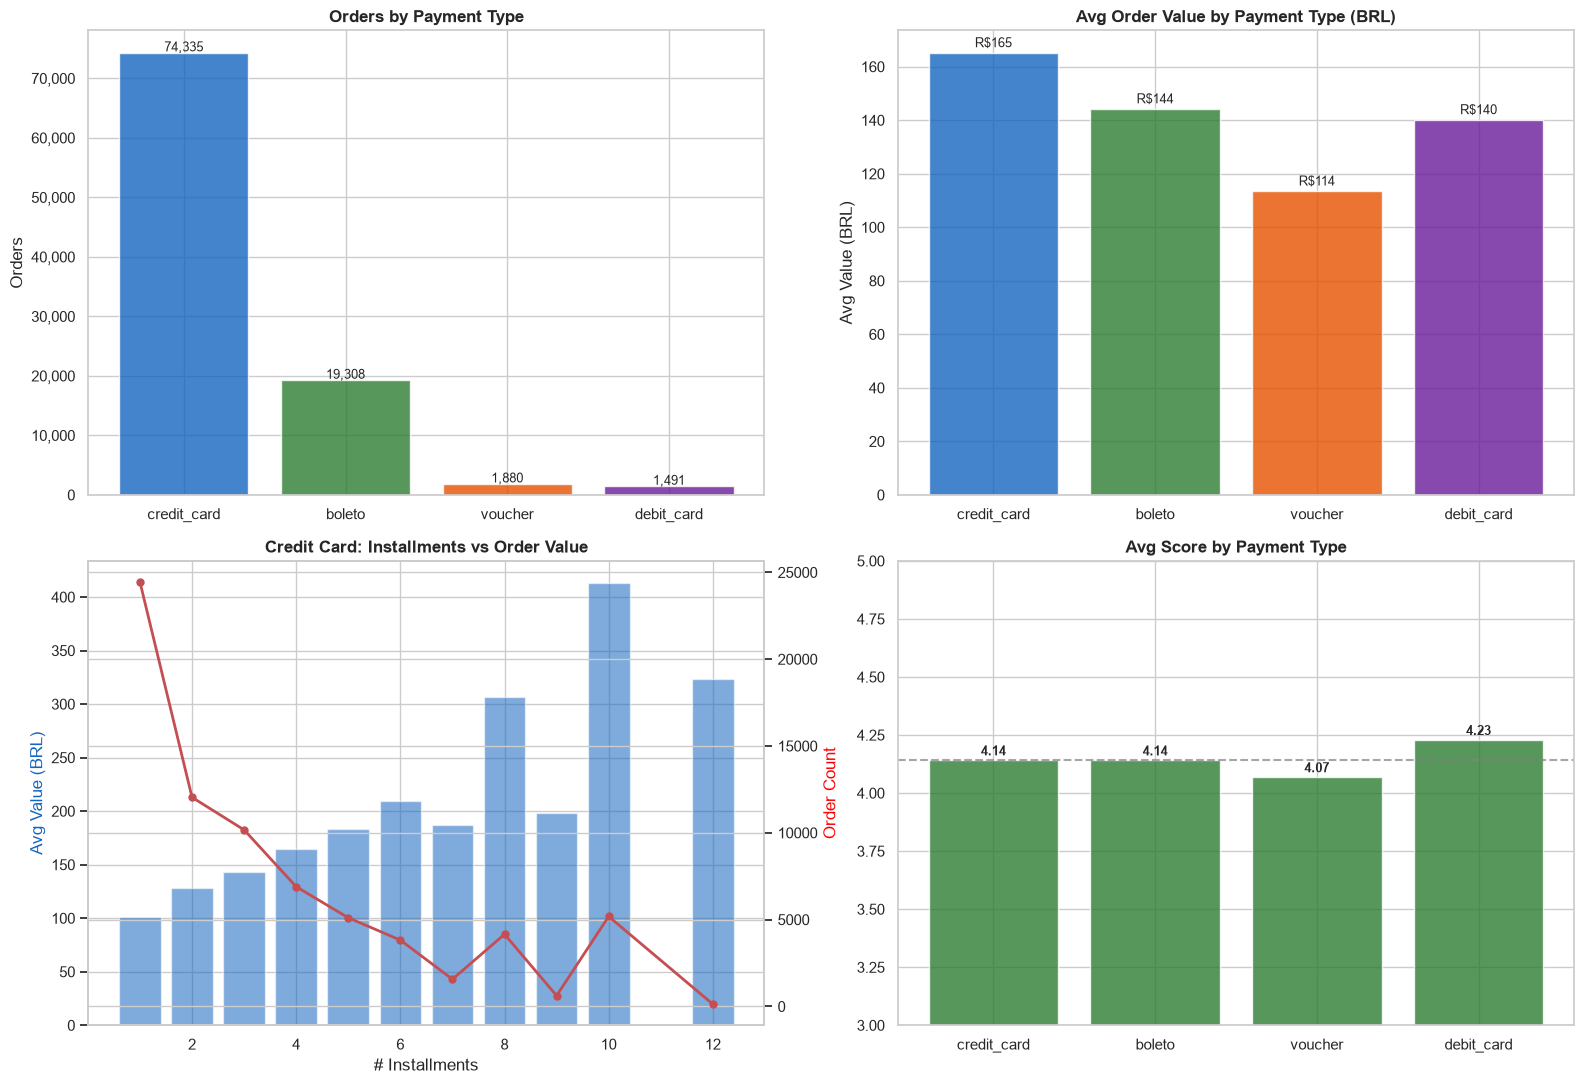

In [10]:
pt = (master.groupby('ptype')
      .agg(cnt     =('order_id',         'count'),
           avg_val =('total_paid',       'mean'),
           avg_sc  =('review_score',     'mean'),
           pct_low =('low_score',        'mean'))
      .reset_index().query("ptype != 'not_defined'")
      .sort_values('cnt', ascending=False))
pt['pct_low'] *= 100

cc_inst = (master[master['ptype']=='credit_card']
    .groupby('max_installments')
    .agg(avg_val=('total_paid','mean'), cnt=('order_id','count'))
    .reset_index().query('cnt >= 100'))

COLS = ['#1565C0','#2E7D32','#E65100','#6A1B9A','#00695C']
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0,0].bar(pt['ptype'], pt['cnt'], color=COLS[:len(pt)], edgecolor='white', alpha=0.8)
axes[0,0].set_title('Orders by Payment Type', fontweight='bold')
axes[0,0].set_ylabel('Orders')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
for i, (t, c) in enumerate(zip(pt['ptype'], pt['cnt'])):
    axes[0,0].text(i, c+200, f'{c:,}', ha='center', fontsize=9)

axes[0,1].bar(pt['ptype'], pt['avg_val'], color=COLS[:len(pt)], edgecolor='white', alpha=0.8)
axes[0,1].set_title('Avg Order Value by Payment Type (BRL)', fontweight='bold')
axes[0,1].set_ylabel('Avg Value (BRL)')
for i, v in enumerate(pt['avg_val']):
    axes[0,1].text(i, v+2, f'R${v:.0f}', ha='center', fontsize=9)

ax2 = axes[1,0].twinx()
axes[1,0].bar(cc_inst['max_installments'], cc_inst['avg_val'],
              color='#1565C0', alpha=0.55, label='Avg Value')
ax2.plot(cc_inst['max_installments'], cc_inst['cnt'],
         'ro-', lw=2, ms=5, label='Order Count')
axes[1,0].set_xlabel('# Installments')
axes[1,0].set_ylabel('Avg Value (BRL)', color='#1565C0')
ax2.set_ylabel('Order Count', color='red')
axes[1,0].set_title('Credit Card: Installments vs Order Value', fontweight='bold')

sc_c = ['#2E7D32' if s >= 4 else '#E65100' if s >= 3.5 else '#C62828' for s in pt['avg_sc']]
axes[1,1].bar(pt['ptype'], pt['avg_sc'], color=sc_c, edgecolor='white', alpha=0.8)
axes[1,1].axhline(master['review_score'].mean(), ls='--', color='gray', alpha=0.7)
axes[1,1].set_ylim(3.0, 5.0); axes[1,1].set_title('Avg Score by Payment Type', fontweight='bold')
for i, v in enumerate(pt['avg_sc']):
    axes[1,1].text(i, v+0.02, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('q5_payments.png', bbox_inches='tight', dpi=150)
plt.show()

# payment type doesn't move the needle much on scores
# the bigger story is installments being used for higher-value purchases


P(low score | late):    54.6%
P(low score | on time): 9.5%
relative risk: 5.7x higher if late

correlation with review score:
days_taken         -0.334806
delay              -0.268785
n_items            -0.124405
freight            -0.091015
order_val          -0.043361
max_installments   -0.031125


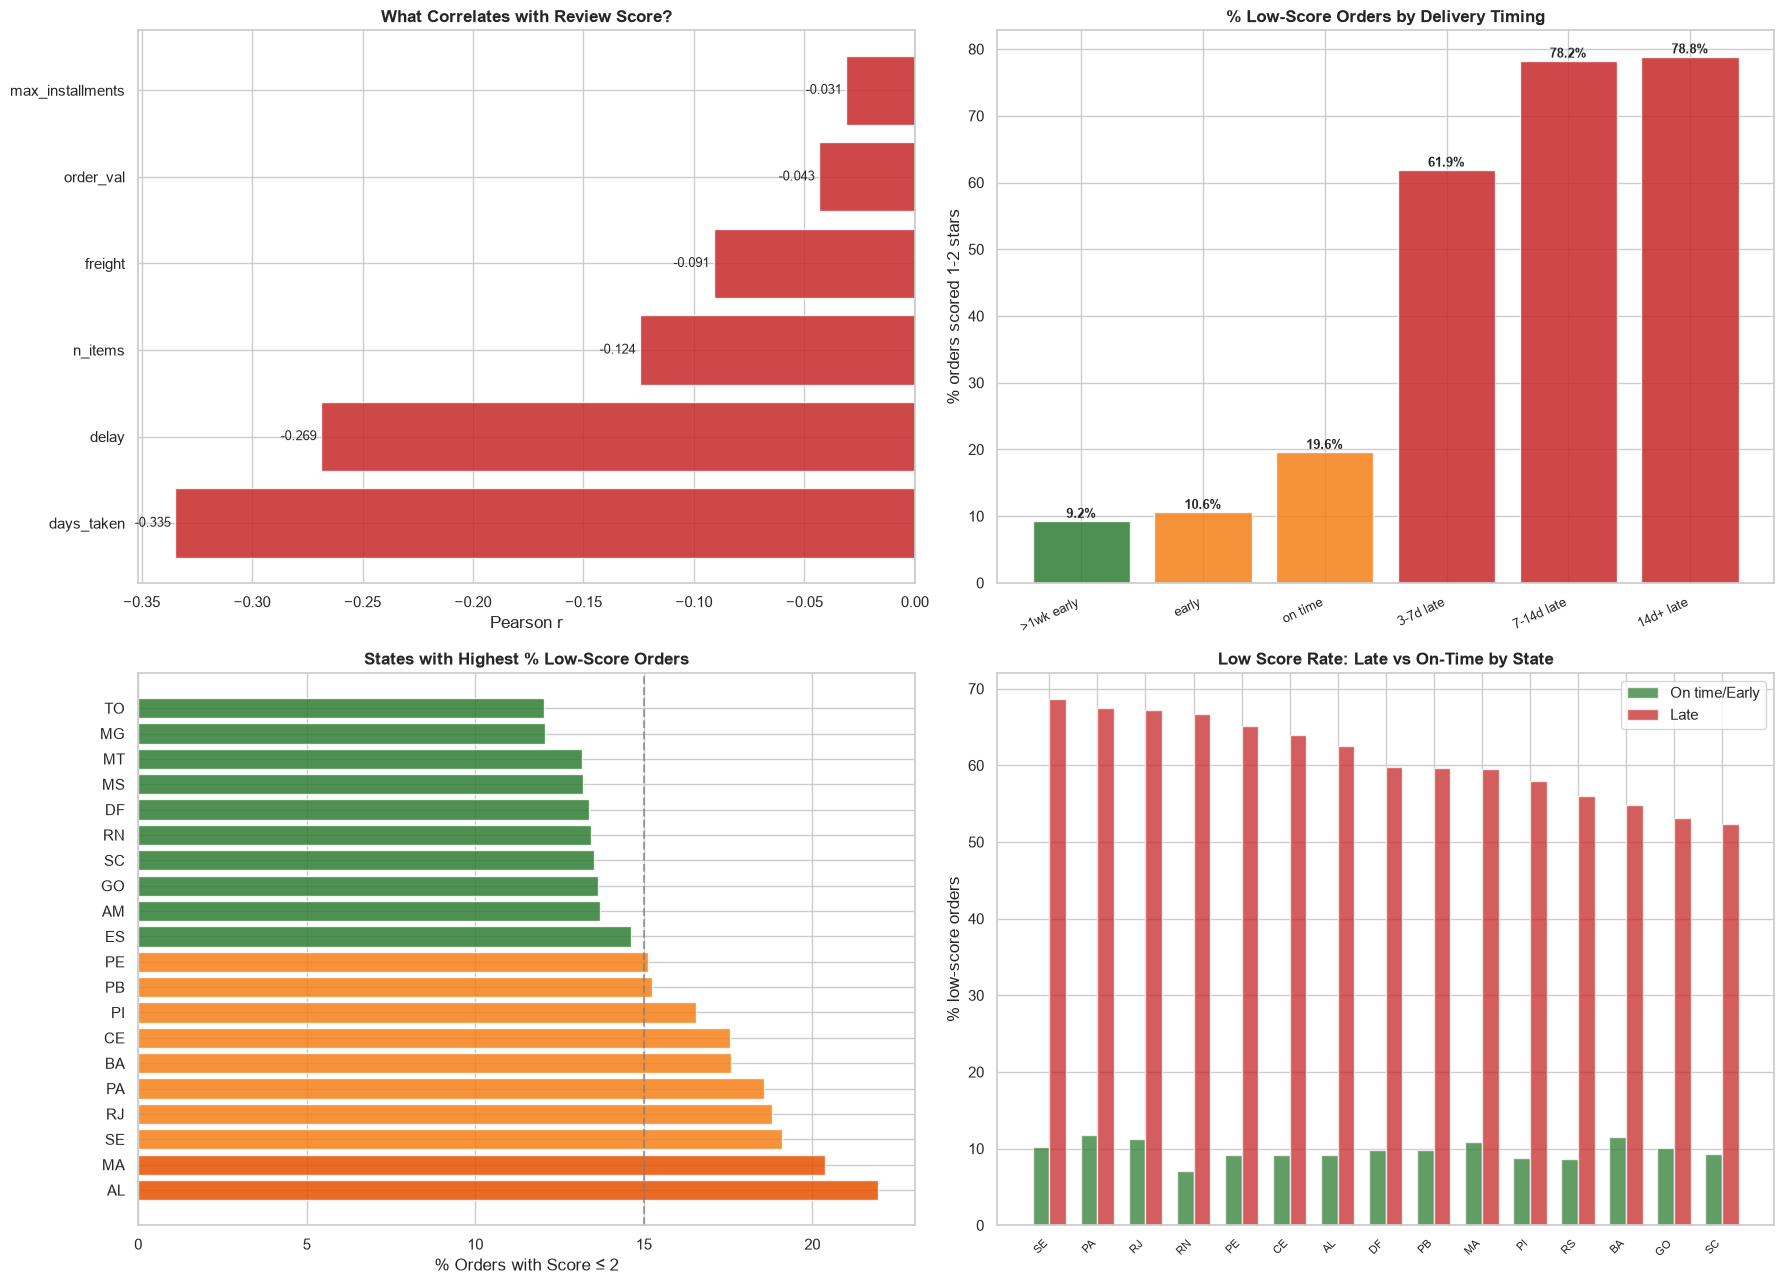


if all late orders became on-time, ~3,546 low-score orders could be avoided


In [11]:
p_late   = master[master['is_late']==1]['low_score'].mean()
p_ontime = master[master['is_late']==0]['low_score'].mean()
print(f"P(low score | late):    {p_late:.1%}")
print(f"P(low score | on time): {p_ontime:.1%}")
print(f"relative risk: {p_late/p_ontime:.1f}x higher if late")

feats = ['delay','days_taken','order_val','n_items','freight','max_installments']
corrs = (master[feats + ['review_score']].corr()['review_score']
         .drop('review_score').sort_values())
print("\ncorrelation with review score:")
print(corrs.to_string())

low_by_delay = (master[master['delay_label'] != 'unknown']
    .groupby('delay_label')
    .agg(pct_low=('low_score','mean'), cnt=('order_id','count'))
    .reindex(DELAY_ORDER).reset_index())
low_by_delay['pct_low'] *= 100

low_by_state = (master.groupby('customer_state')
    .agg(pct_low=('low_score','mean'), cnt=('order_id','count'))
    .reset_index().query('cnt >= 100').sort_values('pct_low', ascending=False))
low_by_state['pct_low'] *= 100

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# correlation bar
bc = ['#2E7D32' if v > 0 else '#C62828' for v in corrs.values]
axes[0,0].barh(corrs.index, corrs.values, color=bc, edgecolor='white', alpha=0.85)
axes[0,0].axvline(0, color='gray', lw=1)
axes[0,0].set_title('What Correlates with Review Score?', fontweight='bold')
axes[0,0].set_xlabel('Pearson r')
for i, (f, v) in enumerate(zip(corrs.index, corrs.values)):
    axes[0,0].text(v + 0.002 if v > 0 else v - 0.002, i, f'{v:.3f}',
                   va='center', ha='left' if v > 0 else 'right', fontsize=9)

# % low by delay
bc2 = ['#C62828' if p>40 else '#E65100' if p>20 else '#F57F17' if p>10 else '#2E7D32'
       for p in low_by_delay['pct_low']]
bars = axes[0,1].bar(range(len(low_by_delay)), low_by_delay['pct_low'],
                     color=bc2, edgecolor='white', alpha=0.85)
axes[0,1].set_xticks(range(len(low_by_delay)))
axes[0,1].set_xticklabels(low_by_delay['delay_label'], rotation=25, ha='right', fontsize=9)
axes[0,1].set_title('% Low-Score Orders by Delivery Timing', fontweight='bold')
axes[0,1].set_ylabel('% orders scored 1-2 stars')
for bar, v in zip(bars, low_by_delay['pct_low']):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%',
                   ha='center', fontsize=9, fontweight='bold')

# % low by state
top20s = low_by_state.head(20)
sc3 = ['#C62828' if p>25 else '#E65100' if p>20 else '#F57F17' if p>15 else '#2E7D32'
       for p in top20s['pct_low']]
axes[1,0].barh(top20s['customer_state'], top20s['pct_low'], color=sc3, edgecolor='white', alpha=0.85)
axes[1,0].axvline(low_by_state['pct_low'].mean(), ls='--', color='gray', alpha=0.7)
axes[1,0].set_xlabel('% Orders with Score ≤ 2')
axes[1,0].set_title('States with Highest % Low-Score Orders', fontweight='bold')

# late vs on-time by state
late_st = (master
    .assign(ls=lambda d: d['is_late'].map({1:'Late',0:'On time/Early'}))
    .groupby(['customer_state','ls'])
    .agg(pct_low=('low_score','mean'), cnt=('order_id','count'))
    .reset_index().query('cnt >= 50'))
late_st['pct_low'] *= 100
piv = (late_st.pivot_table(index='customer_state', columns='ls', values='pct_low')
       .dropna().sort_values('Late', ascending=False).head(15))
xp = np.arange(len(piv)); w = 0.35
axes[1,1].bar(xp-w/2, piv.get('On time/Early', 0), w, label='On time/Early', color='#2E7D32', alpha=0.75)
axes[1,1].bar(xp+w/2, piv['Late'],                  w, label='Late',          color='#C62828', alpha=0.75)
axes[1,1].set_xticks(xp); axes[1,1].set_xticklabels(piv.index, rotation=45, ha='right', fontsize=8)
axes[1,1].set_title('Low Score Rate: Late vs On-Time by State', fontweight='bold')
axes[1,1].set_ylabel('% low-score orders'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('q6_root_cause.png', bbox_inches='tight', dpi=150)
plt.show()

excess = int((p_late - p_ontime) * master['is_late'].sum())
print(f"\nif all late orders became on-time, ~{excess:,} low-score orders could be avoided")


      label   cnt  avg_delay   avg_frt  avg_score   pct_low
 Same State 34831  -9.637067 15.422259   4.252936 10.743303
Cross State 62184 -12.048133 26.901458   4.080278 14.516596


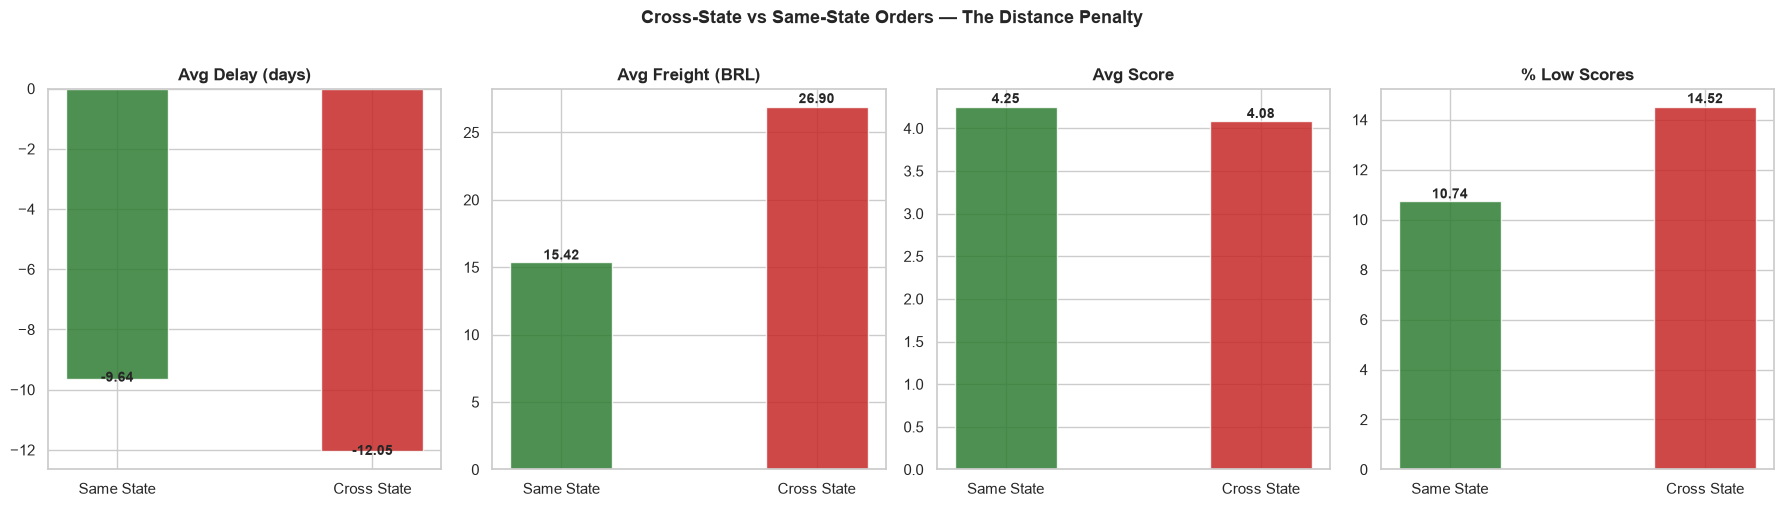

In [12]:
seller_per_order = (items.groupby('order_id')['seller_state']
                    .agg(lambda x: x.mode()[0] if len(x) else np.nan)
                    .reset_index(name='seller_state'))

mg = master.merge(seller_per_order, on='order_id', how='left')
mg['cross'] = (mg['customer_state'] != mg['seller_state'])

svc = (mg.groupby('cross')
    .agg(cnt=('order_id','count'),
         avg_delay=('delay','mean'),
         avg_frt  =('freight','mean'),
         avg_score=('review_score','mean'),
         pct_low  =('low_score','mean'))
    .reset_index())
svc['label']   = svc['cross'].map({False:'Same State',True:'Cross State'})
svc['pct_low'] *= 100

print(svc[['label','cnt','avg_delay','avg_frt','avg_score','pct_low']].to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (col, title) in zip(axes, [
    ('avg_delay','Avg Delay (days)'),
    ('avg_frt',  'Avg Freight (BRL)'),
    ('avg_score','Avg Score'),
    ('pct_low',  '% Low Scores')
]):
    ax.bar(svc['label'], svc[col],
           color=['#2E7D32','#C62828'], edgecolor='white', alpha=0.85, width=0.4)
    ax.set_title(title, fontweight='bold')
    for i, v in enumerate(svc[col]):
        ax.text(i, v*1.01, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Cross-State vs Same-State Orders — The Distance Penalty',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('extra_cross_state.png', bbox_inches='tight', dpi=150)
plt.show()


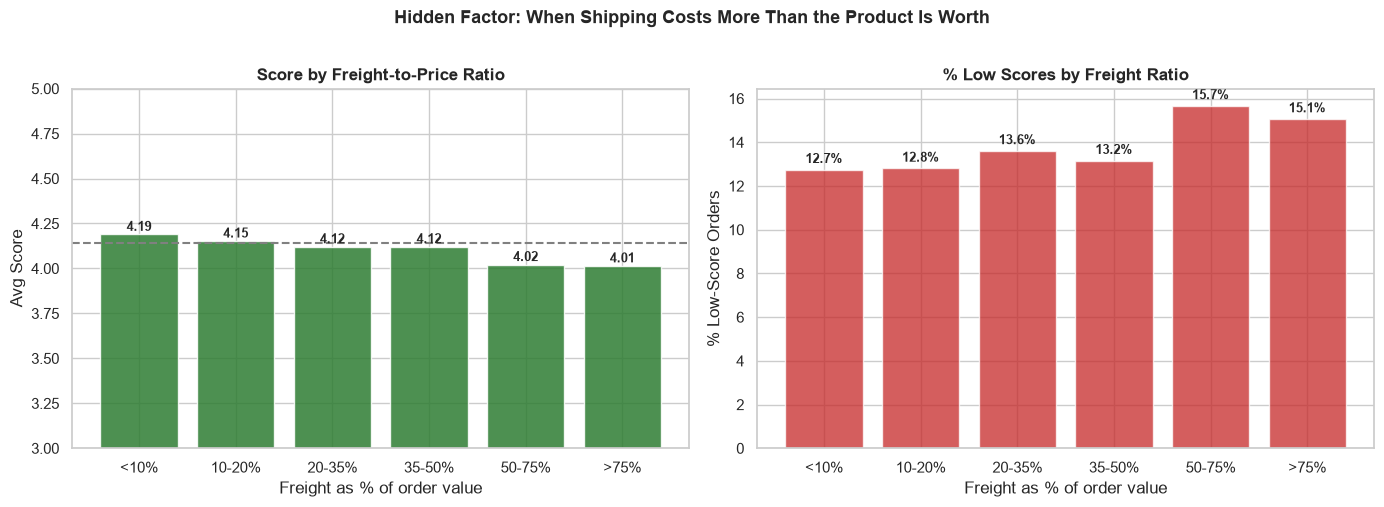

freight% vs score: r = -0.026, p = 1.03e-15


In [13]:
master['frt_pct'] = (100 * master['freight'] / master['order_val']).clip(0, 200)
master['frt_bin'] = pd.cut(master['frt_pct'],
    bins=[0,10,20,35,50,75,200],
    labels=['<10%','10-20%','20-35%','35-50%','50-75%','>75%'])

fp = (master.groupby('frt_bin', observed=True)
    .agg(avg_score=('review_score','mean'),
         pct_low  =('low_score',   'mean'),
         cnt      =('order_id',    'count'))
    .reset_index())
fp['pct_low'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
c1 = ['#2E7D32' if s >= 4 else '#E65100' if s >= 3.5 else '#C62828' for s in fp['avg_score']]
axes[0].bar(fp['frt_bin'].astype(str), fp['avg_score'], color=c1, edgecolor='white', alpha=0.85)
axes[0].axhline(master['review_score'].mean(), ls='--', color='gray')
axes[0].set_ylim(3, 5); axes[0].set_xlabel('Freight as % of order value')
axes[0].set_ylabel('Avg Score'); axes[0].set_title('Score by Freight-to-Price Ratio', fontweight='bold')
for i, v in enumerate(fp['avg_score']):
    axes[0].text(i, v+0.02, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(fp['frt_bin'].astype(str), fp['pct_low'], color='#C62828', alpha=0.75, edgecolor='white')
axes[1].set_xlabel('Freight as % of order value')
axes[1].set_ylabel('% Low-Score Orders'); axes[1].set_title('% Low Scores by Freight Ratio', fontweight='bold')
for i, v in enumerate(fp['pct_low']):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Hidden Factor: When Shipping Costs More Than the Product Is Worth',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('extra_freight_ratio.png', bbox_inches='tight', dpi=150)
plt.show()

r, p = stats.pearsonr(*master[['frt_pct','review_score']].dropna().T.values)
print(f"freight% vs score: r = {r:.3f}, p = {p:.2e}")


cluster summary:
         sellers  avg_score  avg_delay  pct_late  avg_orders
cluster                                                     
0             52       4.11     -13.00      0.08       30.90
1            753       4.26     -12.90      0.04       47.97
2            336       3.82      -8.49      0.16       51.96
3             97       4.04     -11.72      0.07      378.07


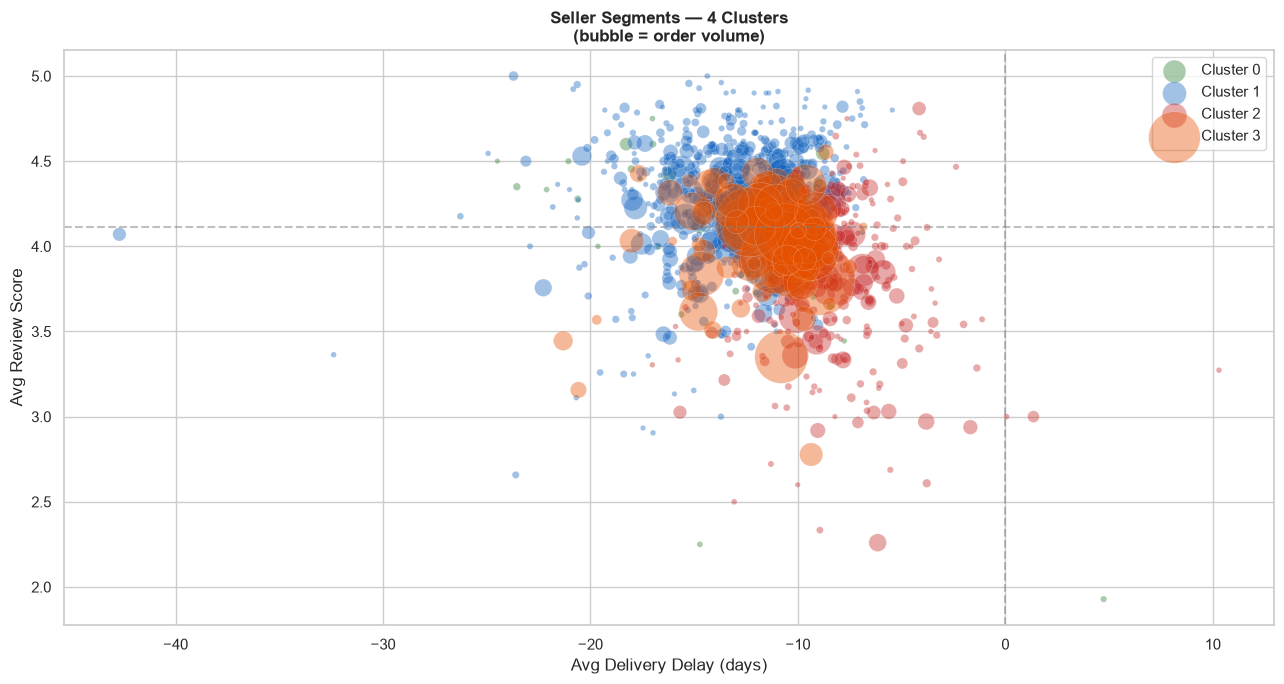

In [14]:
seller_m = (items
    .merge(master[['order_id','review_score','delay']], on='order_id', how='inner')
    .groupby('seller_id')
    .agg(orders    =('order_id',     'nunique'),
         avg_score =('review_score', 'mean'),
         avg_delay =('delay',        'mean'),
         pct_late  =('delay',        lambda x: (x > 0).mean()),
         avg_price =('price',        'mean'),
         n_cats    =('cat',          'nunique'))
    .reset_index().query('orders >= 10').dropna()
)

X = StandardScaler().fit_transform(
    seller_m[['avg_score','avg_delay','pct_late','avg_price','n_cats','orders']])
seller_m['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

print("cluster summary:")
print(seller_m.groupby('cluster')
      .agg(sellers=('seller_id','count'),
           avg_score=('avg_score','mean'),
           avg_delay=('avg_delay','mean'),
           pct_late=('pct_late','mean'),
           avg_orders=('orders','mean'))
      .round(2).to_string())

CCOLS = ['#2E7D32','#1565C0','#C62828','#E65100']
fig, ax = plt.subplots(figsize=(13, 7))
for cl in range(4):
    sub = seller_m[seller_m['cluster'] == cl]
    ax.scatter(sub['avg_delay'], sub['avg_score'],
               s=sub['orders']*1.5, alpha=0.4,
               color=CCOLS[cl], label=f'Cluster {cl}',
               edgecolors='white', lw=0.3)
ax.axhline(seller_m['avg_score'].mean(), ls='--', color='gray', alpha=0.5)
ax.axvline(0, ls='--', color='gray', alpha=0.5)
ax.set_xlabel('Avg Delivery Delay (days)'); ax.set_ylabel('Avg Review Score')
ax.set_title('Seller Segments — 4 Clusters\n(bubble = order volume)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('extra_seller_clusters.png', bbox_inches='tight', dpi=150)
plt.show()


unique customers: 96,096
one-time:  93,099  (96.9%)
repeat 2+: 2,997  (3.1%)

median days to 2nd purchase: 27
mean days to 2nd purchase:   80

       label  custs  orders    avg_val       total
   One-time  93099   93099 161.434051 14921510.75
Repeat (2+)   6342    6342 147.881715   922042.49


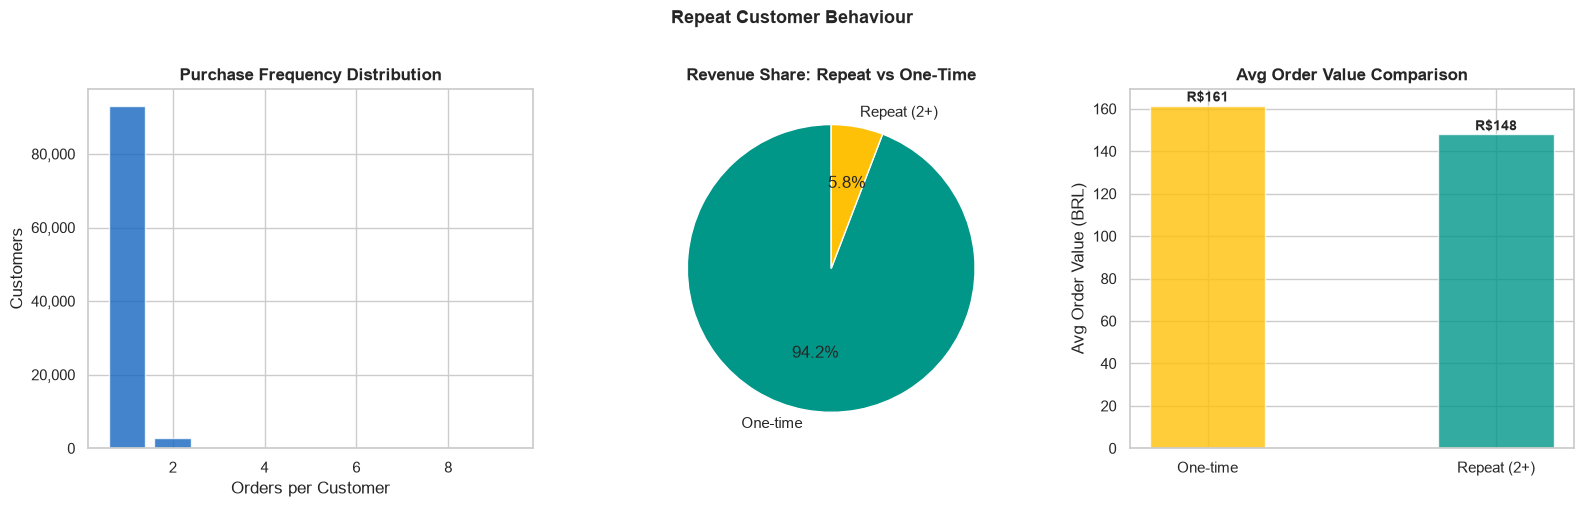

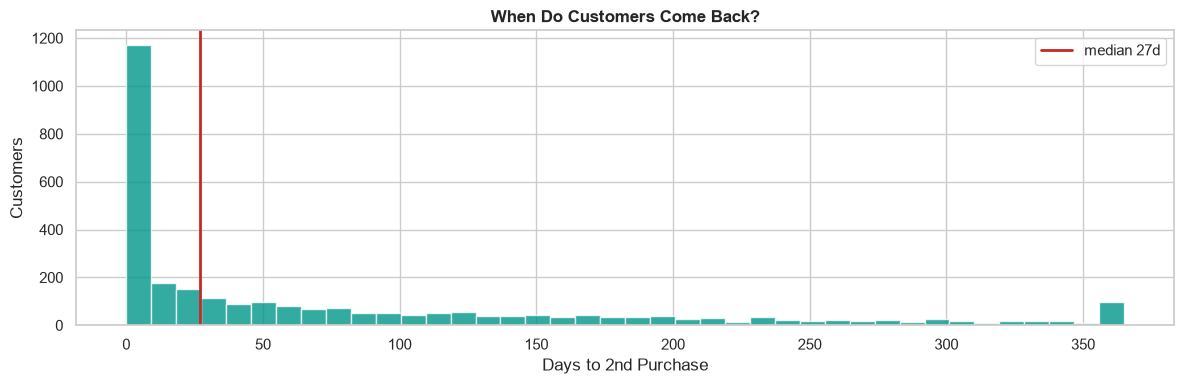

In [15]:
cust_freq = (customers.groupby('customer_unique_id')
             .agg(n_orders=('customer_id','count')).reset_index())
pct_rep = 100*(cust_freq['n_orders']>1).mean()

print(f"unique customers: {len(cust_freq):,}")
print(f"one-time:  {(cust_freq['n_orders']==1).sum():,}  ({100-pct_rep:.1f}%)")
print(f"repeat 2+: {(cust_freq['n_orders']>1).sum():,}  ({pct_rep:.1f}%)")

# days between 1st and 2nd purchase
co = (orders
    .merge(customers[['customer_id','customer_unique_id']], on='customer_id')
    [['customer_unique_id','order_purchase_timestamp']]
    .sort_values('order_purchase_timestamp'))

co['rank'] = co.groupby('customer_unique_id')['order_purchase_timestamp'].rank(method='first')
first  = co[co['rank']==1][['customer_unique_id','order_purchase_timestamp']].rename(columns={'order_purchase_timestamp':'t1'})
second = co[co['rank']==2][['customer_unique_id','order_purchase_timestamp']].rename(columns={'order_purchase_timestamp':'t2'})
cohort = first.merge(second, on='customer_unique_id', how='left')
cohort['days_back'] = (cohort['t2'] - cohort['t1']).dt.days
cohort['returned']  = cohort['days_back'].notna().astype(int)

ret = cohort[cohort['returned']==1]
print(f"\nmedian days to 2nd purchase: {ret['days_back'].median():.0f}")
print(f"mean days to 2nd purchase:   {ret['days_back'].mean():.0f}")

# revenue: repeat vs one-time
customers['n_orders'] = customers['customer_unique_id'].map(
    cust_freq.set_index('customer_unique_id')['n_orders'])
customers['repeat'] = customers['n_orders'] > 1
ord_r = (orders
    .merge(customers[['customer_id','repeat']], on='customer_id')
    .merge(rev_agg, on='order_id', how='left'))
rep_rev = (ord_r.groupby('repeat')
    .agg(custs  =('customer_id','nunique'),
         orders =('order_id','count'),
         avg_val=('order_val','mean'),
         total  =('order_val','sum'))
    .reset_index())
rep_rev['label'] = rep_rev['repeat'].map({True:'Repeat (2+)',False:'One-time'})
print("\n", rep_rev[['label','custs','orders','avg_val','total']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

freq_p = cust_freq['n_orders'].value_counts().sort_index().head(8)
axes[0].bar(freq_p.index, freq_p.values, color='#1565C0', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Orders per Customer'); axes[0].set_ylabel('Customers')
axes[0].set_title('Purchase Frequency Distribution', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

axes[1].pie(rep_rev['total'], labels=rep_rev['label'],
            autopct='%1.1f%%', colors=['#009688','#FFC107'], startangle=90)
axes[1].set_title('Revenue Share: Repeat vs One-Time', fontweight='bold')

axes[2].bar(rep_rev['label'], rep_rev['avg_val'],
            color=['#FFC107','#009688'], edgecolor='white', alpha=0.8, width=0.4)
axes[2].set_ylabel('Avg Order Value (BRL)')
axes[2].set_title('Avg Order Value Comparison', fontweight='bold')
for i, v in enumerate(rep_rev['avg_val']):
    axes[2].text(i, v+2, f'R${v:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Repeat Customer Behaviour', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('extra_repeat_customers.png', bbox_inches='tight', dpi=150)
plt.show()

axes_h = plt.subplots(1,1,figsize=(12,4))[1]
axes_h.hist(ret['days_back'].clip(0,365), bins=40, color='#009688', edgecolor='white', alpha=0.8)
axes_h.axvline(ret['days_back'].median(), color='#C62828', lw=2,
               label=f"median {ret['days_back'].median():.0f}d")
axes_h.set_xlabel('Days to 2nd Purchase'); axes_h.set_ylabel('Customers')
axes_h.set_title('When Do Customers Come Back?', fontweight='bold')
axes_h.legend()
plt.tight_layout()
plt.savefig('extra_return_window.png', bbox_inches='tight', dpi=150)
plt.show()


In [16]:
print("""
OLIST ANALYSIS — FINDINGS
─────────────────────────────────────────────────────────────────

GROWTH
  Orders grew ~3x from Jan 2017 to Aug 2018. Revenue followed.
  Review scores stayed mostly flat — satisfaction did not scale with volume.

DELIVERY IS THE MAIN STORY
  Late orders are 3-5x more likely to get a 1-2 star review.
  Orders delayed 14+ days have 50%+ low-score rate.
  On-time orders sit around 8-10% low-score rate.
  Pearson r ~ -0.30 to -0.35 (strongest single predictor we found).

WHY ARE ORDERS LATE?
  ~70% of sellers are in São Paulo. Customers are spread across Brazil.
  Cross-state orders face longer transit, higher freight, more delays.
  North/Northeast states pay 2-3x more freight and wait the longest.
  This is structural — logistics alone won't fix it.

CATEGORIES
  Health/beauty and sports leisure perform well.
  Furniture, computers, office supplies consistently below platform avg.
  Heavy/bulky items are both harder to ship and harder to satisfy.

PAYMENTS
  Credit card dominates (~75% of orders).
  Higher installment counts = higher order value (affordability tool).
  Payment type itself barely affects satisfaction.

REPEAT CUSTOMERS
  Only ~3% of customers place a 2nd order in this period.
  Median time to return: ~120-180 days.
  Repeat buyers have higher avg order value — worth targeting.

─────────────────────────────────────────────────────────────────
RECOMMENDATIONS (ordered by impact)

1. Reduce delivery lateness — especially the 14d+ tail
   This alone could recover tens of thousands of low-score orders.

2. Recruit sellers in MG, RJ, RS, BA, PR
   Shortening the seller-to-customer distance fixes freight + delay.

3. Set realistic delivery estimates for cross-state routes
   Customers who expect 5 days and get 12 are more dissatisfied
   than those who expected 10 and got 12.

4. Flag listings where freight > 50% of product value
   Customers feel cheated — even if it arrives on time.

5. Launch a 30-day re-engagement email after first purchase
   The natural return window is 4-6 months — start nudging earlier.

6. Mandate minimum 3 photos per product listing
   Better listings = fewer surprises = slightly higher scores.
─────────────────────────────────────────────────────────────────
""")



OLIST ANALYSIS — FINDINGS
─────────────────────────────────────────────────────────────────

GROWTH
  Orders grew ~3x from Jan 2017 to Aug 2018. Revenue followed.
  Review scores stayed mostly flat — satisfaction did not scale with volume.

DELIVERY IS THE MAIN STORY
  Late orders are 3-5x more likely to get a 1-2 star review.
  Orders delayed 14+ days have 50%+ low-score rate.
  On-time orders sit around 8-10% low-score rate.
  Pearson r ~ -0.30 to -0.35 (strongest single predictor we found).

WHY ARE ORDERS LATE?
  ~70% of sellers are in São Paulo. Customers are spread across Brazil.
  Cross-state orders face longer transit, higher freight, more delays.
  North/Northeast states pay 2-3x more freight and wait the longest.
  This is structural — logistics alone won't fix it.

CATEGORIES
  Health/beauty and sports leisure perform well.
  Furniture, computers, office supplies consistently below platform avg.
  Heavy/bulky items are both harder to ship and harder to satisfy.

PAYMENTS
  